In [1]:
# Key and llm initialization
import os
from langchain_openai import ChatOpenAI

c:\Users\Admin\Documents\ML_Projects\Agentic_AI\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Now you can access your environment variables using os.environ
os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY")
os.environ['TAVILY_API_KEY'] = os.getenv("TAVILY_API_KEY")

In [3]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [4]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
tavily_tool = TavilySearchResults(max_results=5)

C:\Users\Admin\AppData\Local\Temp\ipykernel_19040\2368514273.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(max_results=5)


In [5]:


from pydantic import BaseModel, Field
from typing import  Literal
from langchain_core.tools import tool
from langgraph.graph import MessagesState

In [6]:
# Pydantic object for structed output
class CityDetails(BaseModel):
    """respond to user with this"""
    state_name: str = Field(description="State name of the city")
    state_capital: str = Field(description="state capital of the city")
    country_name: str = Field(description="Country caital of the city")


In [7]:
# Inherit 'messages' key from MessagesState, which is a list of chat messages
class AgentState(MessagesState):
    # Final structured response from the agent
    final_response:CityDetails

In [9]:
# Python function to tool creation
@tool
def get_city_details(prompt):
    "Should do a web search o fins the required city details"
    response = tavily_tool.invoke(prompt)
    return response

tools = [get_city_details]

# Two llm models
model_with_tools = llm.bind_tools(tools)
model_with_structured_ouptut = llm.with_structured_output(CityDetails)

In [11]:
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage

# Define the function that calls the model
def call_model(state: AgentState):
    response = model_with_tools.invoke(state['messages'])
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}

# Define the function that responds to the user
def respond(state: AgentState):
    response = model_with_structured_ouptut.invoke([HumanMessage(content=state['messages'][-2].content)])
    # We return the final answer
    return {"final_response": response}

# Define the function that determines whether to continue or not
def should_continue(state: AgentState):
    messages = state["messages"]
    last_message = messages[-1]
    # If there is no function call, then we respond to the user
    if not last_message.tool_calls:
        return "respond"
    # Otherwise if there is, we continue
    else:
        return "continue"

In [14]:
# Define a new graph
workflow = StateGraph(AgentState)

# Define the two nodes we will clycle between
workflow.add_node("agent", call_model)
workflow.add_node("respond", respond)
workflow.add_node("tools", ToolNode(tools))

# Set the entrypoint as `agent`
# This means that this node is the first one called
workflow.set_entry_point("agent")

# We now add a conditional edge
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "tools",
        "respond": "respond"
    },
)

workflow.add_edge("tools", "agent")
workflow.add_edge("respond", END)
graph = workflow.compile()

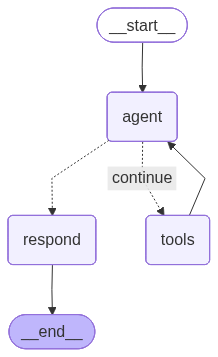

In [15]:
graph

In [17]:
answer = graph.invoke(input={"messages": [("human", "Tell me about the city details for Bangalore?")]})['final_response']

In [18]:
for s in graph.stream({
        "messages": [HumanMessage(content="Tell me about the city details for Bangalore?")]
    }
):
    if "__end__" not in s:
        print(s)
        print("----")

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 59, 'total_tokens': 77, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c34fdfcd04', 'id': 'chatcmpl-DbWC8V55IIr7iCEIpgIQhlXz7Kbcm', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019def2e-068f-7903-b0a3-41b2426f5ae5-0', tool_calls=[{'name': 'get_city_details', 'args': {'prompt': 'Bangalore city details'}, 'id': 'call_2JeHSUw55N73p7N2l1DPz5WJ', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 59, 'output_tokens': 18, 'total_tokens': 77, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details'